In [2]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [3]:
# System and Utilities
import re
import string
from collections import Counter

# Core Data Science & Analysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import trange

# Natural Language Processing (NLTK)
import nltk
from nltk import tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import WordNetLemmatizer

# Datasets & Machine Learning (Scikit-Learn)
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [4]:
# Import the dataset

ds = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print (ds)

DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})


In [5]:
#Convert samples into one dataframe and label its source
dfs = []
for sample_name in ds.keys():
    df_sample = ds[sample_name].to_pandas()
    df_sample['task_split'] = sample_name  # track the sample origin
    dfs.append(df_sample)

# Creat one master DataFrame
df = pd.concat(dfs, ignore_index=True)

In [7]:
import os

# Create the data/raw directory if it doesn't exist
os.makedirs('data/raw', exist_ok=True)

# Save your dataframe
df.to_csv('data/raw/my_dataset.csv', index=False)

In [6]:
#check
print(df)

                                      original_abstract  \
0     كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...   
1     يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...   
2     شكلت تلك الجهود والمساعي الرائدة التي قام بها ...   
3     يقوم المقال على اشكالية الضرائب الغير شرعية في...   
4     تتفق المصادر التاريخية المتوفرة حول موضوع تطور...   
...                                                 ...   
8383  إنّ الدارس لشعر المتنبّي يواجه ثروة لغوية واسع...   
8384  يروم هذا المقال تقديم مقاربة لسانية لنص تراثيّ...   
8385  تعدّ الرّوابط اللّغوية إحدى اللّبنات الأساسية ...   
8386  يمكن صياغة التوقيعات البلاغية وفق المعايير الج...   
8387  يحاول هذا المقال أن يقدم نظرة حول القيم التي ت...   

                               allam_generated_abstract  \
0     يتناول هذا البحث موضوع التعليم بين النساء الأن...   
1     يتناول هذا البحث دراسة انهيار دولة الموحدين من...   
2     هدفت هذه الدراسة إلى تسليط الضوء على جهود قادة...   
3     يتناول هذا البحث إشكالية الضرائب غير الشرعية ف...

In [6]:
# Check rows and columns (should output: (8388, 6))
print(df.shape)

(8388, 6)


In [7]:
# column names and data types
df.info()

# first 5 rows across all columns
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   original_abstract          8388 non-null   str  
 1   allam_generated_abstract   8388 non-null   str  
 2   jais_generated_abstract    8388 non-null   str  
 3   llama_generated_abstract   8388 non-null   str  
 4   openai_generated_abstract  8388 non-null   str  
 5   task_split                 8388 non-null   str  
dtypes: str(6)
memory usage: 49.7 MB


,original_abstract,allam_generated_abstract,jais_generated_abstract,llama_generated_abstract,openai_generated_abstract,task_split
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,يتناول هذا البحث موضوع التعليم بين النساء الأن...,تدرس هذه الدراسة دور المرأة في التعليم في الأن...,يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...,صور نظام التعليم عند المرأة الأندلسية تستند إل...,by_polishing
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,يتناول هذا البحث دراسة انهيار دولة الموحدين من...,كان العامل الثقافي من بين الأسباب الرئيسية الت...,يعد العامل الثقافي أحد أبرز الأسباب التي يعزى ...,انهيار دولة الموحدين يعود بشكل كبير للعوامل ال...,by_polishing
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,هدفت هذه الدراسة إلى تسليط الضوء على جهود قادة...,تدرس هذه الدراسة جهود قادة الثورة الجزائرية خل...,شكلت الجهود التي بذلها قادة الثورة الجزائرية خ...,جهود قادة الثورة الجزائرية خلال المرحلة الأولى...,by_polishing
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,يتناول هذا البحث إشكالية الضرائب غير الشرعية ف...,تدرس المقالة مشكلة الضرائب غير الشرعية في مراح...,يقوم البحث على دراسة الضرائب غير الشرعية في دو...,المقال يناقش قضية الضرائب غير الشرعية في دولتي...,by_polishing
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,تتناول هذه الدراسة حركة الانتصار للحريات الديم...,حركة انتصار الحريات الديمقراطية (MTLD)، وهي حر...,تُظهر المصادر التاريخية المتاحة حول تطور الحرك...,حركة انتصار الحريات الديمقراطية (MTLD) في الجز...,by_polishing


--- Breakdown Per Task Split (Wide Data) ---
               task_split  Human_Count  AI_Count  Total_Samples  Human_%  AI_%
0            by_polishing         2851     11404          14255     20.0  80.0
1              from_title         2963     11852          14815     20.0  80.0
2  from_title_and_content         2574     10296          12870     20.0  80.0


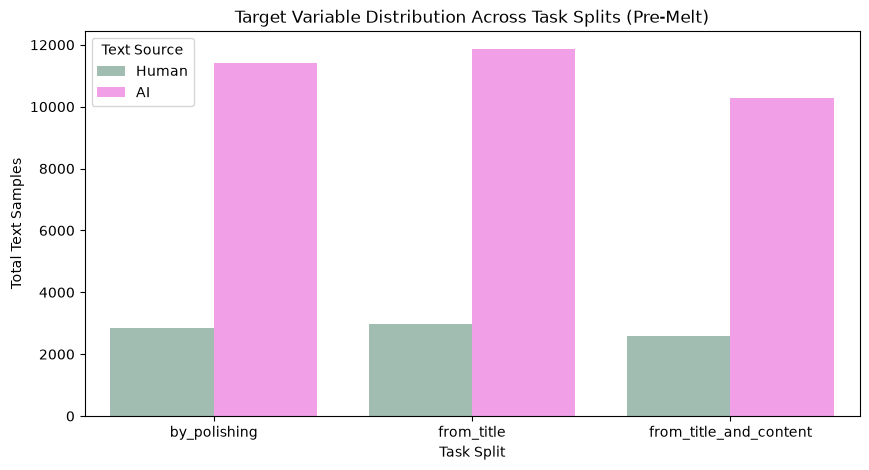

In [8]:

# 1. Count human vs. AI abstracts per split directly from wide format
# Each row has 1 original human abstract and 4 AI-generated abstracts
split_counts = df.groupby('task_split').agg(
    Human_Count=('original_abstract', 'count'),
    AI_Count=('task_split', lambda x: len(x) * 4)  # 4 AI models per row
).reset_index()

# 2. Calculate total samples and percentages
split_counts['Total_Samples'] = split_counts['Human_Count'] + split_counts['AI_Count']
split_counts['Human_%'] = (split_counts['Human_Count'] / split_counts['Total_Samples']) * 100
split_counts['AI_%'] = (split_counts['AI_Count'] / split_counts['Total_Samples']) * 100

print("--- Breakdown Per Task Split (Wide Data) ---")
print(split_counts[['task_split', 'Human_Count', 'AI_Count', 'Total_Samples', 'Human_%', 'AI_%']].round(2))

# 3. Visualize using a grouped bar chart
split_counts_melted = split_counts.melt(
    id_vars=['task_split'], 
    value_vars=['Human_Count', 'AI_Count'], 
    var_name='Label', 
    value_name='Count'
)
split_counts_melted['Label'] = split_counts_melted['Label'].map({'Human_Count': 'Human', 'AI_Count': 'AI'})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=split_counts_melted, 
    x='task_split', 
    y='Count', 
    hue='Label', 
    palette=['#9CC1B2', '#FF92F2']
)
plt.title('Target Variable Distribution Across Task Splits (Pre-Melt)')
plt.xlabel('Task Split')
plt.ylabel('Total Text Samples')
plt.legend(title='Text Source')
plt.show()

In [9]:
#check for any null values 
df.isnull().sum()

original_abstract            0
allam_generated_abstract     0
jais_generated_abstract      0
llama_generated_abstract     0
openai_generated_abstract    0
task_split                   0
dtype: int64

In [10]:
# Check duplicated in human rows
print("Duplicate Human Abstracts:", df['original_abstract'].duplicated().sum())

# Check duplicate in AI rows
for col in ['allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']:
    print(f"Duplicates in {col}:", df[col].duplicated().sum())

Duplicate Human Abstracts: 5396
Duplicates in allam_generated_abstract: 0
Duplicates in jais_generated_abstract: 3
Duplicates in llama_generated_abstract: 0
Duplicates in openai_generated_abstract: 0


In [ ]:
#calculate word count
df_counts = pd.DataFrame()
for col in [
    'original_abstract',
    'allam_generated_abstract',
    'jais_generated_abstract',
    'llama_generated_abstract',
    'openai_generated_abstract',
]:
  df_counts[col] = df[col].apply(lambda x: len(str(x).split()))

#calculate mean,median IQR 
model_stats = []

for col in df_counts.columns:
  series = df_counts[col]
  iqr = series.quantile(0.75) - series.quantile(0.25)

  model_stats.append({
      'Source': col,
      'Mean': series.mean(),
      'Median': series.median(),
      'IQR': iqr,
  })

#Output results as a DataFrame
across_models_stats = pd.DataFrame(model_stats)

print('=== WORD COUNT METRICS ACROSS MODELS ===')
print(across_models_stats.round(2).to_string(index=False))

=== WORD COUNT METRICS ACROSS MODELS ===
                   Source   Mean  Median  IQR
        original_abstract 119.16   110.0 45.0
 allam_generated_abstract  91.93    82.0 45.0
  jais_generated_abstract  77.71    69.0 32.0
 llama_generated_abstract 101.73    99.0 22.0
openai_generated_abstract 134.60   125.0 39.0


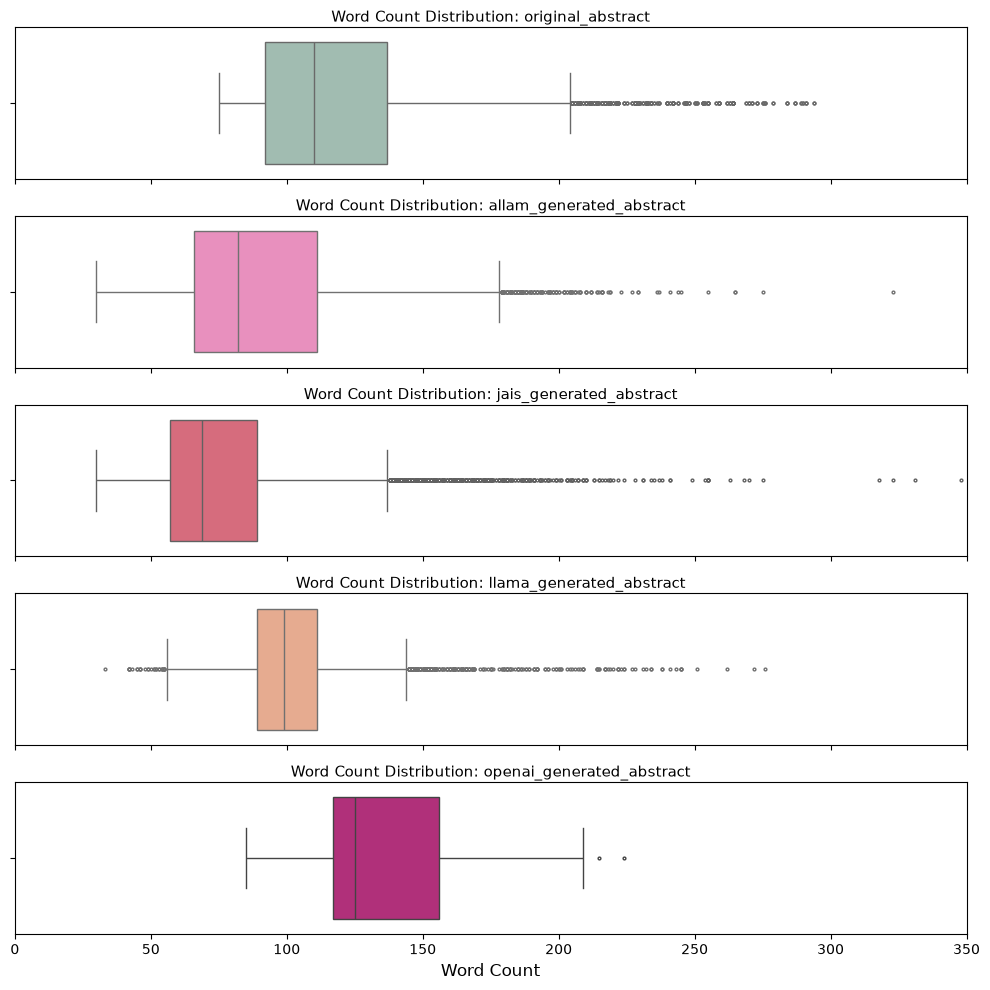

In [8]:
# fairy green is human model, pink shades for AI models
custom_colors = {
    'original_abstract': '#9CC1B2', 
    'allam_generated_abstract': '#f781bf', 
    'jais_generated_abstract': '#e85a71',  
    'llama_generated_abstract': '#f4a582',  
    'openai_generated_abstract': '#c51b7d',  
}

# Create 5 subplots
fig, axes = plt.subplots(
    nrows=5, ncols=1, figsize=(10, 10), sharex=True, squeeze=True
)

for i, col in enumerate(df_counts.columns):
  sns.boxplot(
      data=df_counts,
      x=col,
      ax=axes[i],
      color=custom_colors[col],
      orient='h',
      fliersize=2,  # smaller outlier dots
  )
  axes[i].set_title(f'Word Count Distribution: {col}', fontsize=11, pad=4)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

  # ZOOM IN
  axes[i].set_xlim(0, 350)

# Label the shared x-axis at the bottom
axes[-1].set_xlabel('Word Count', fontsize=12)

plt.tight_layout()
plt.show()

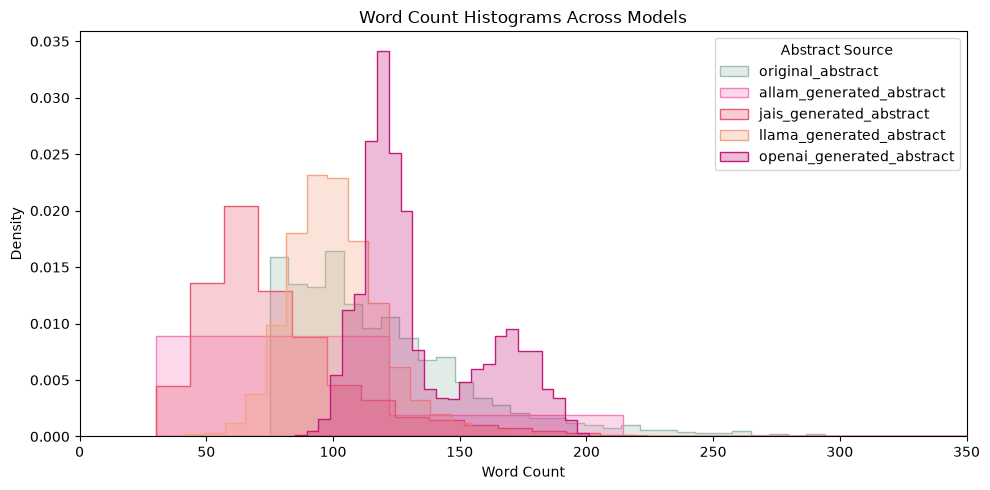

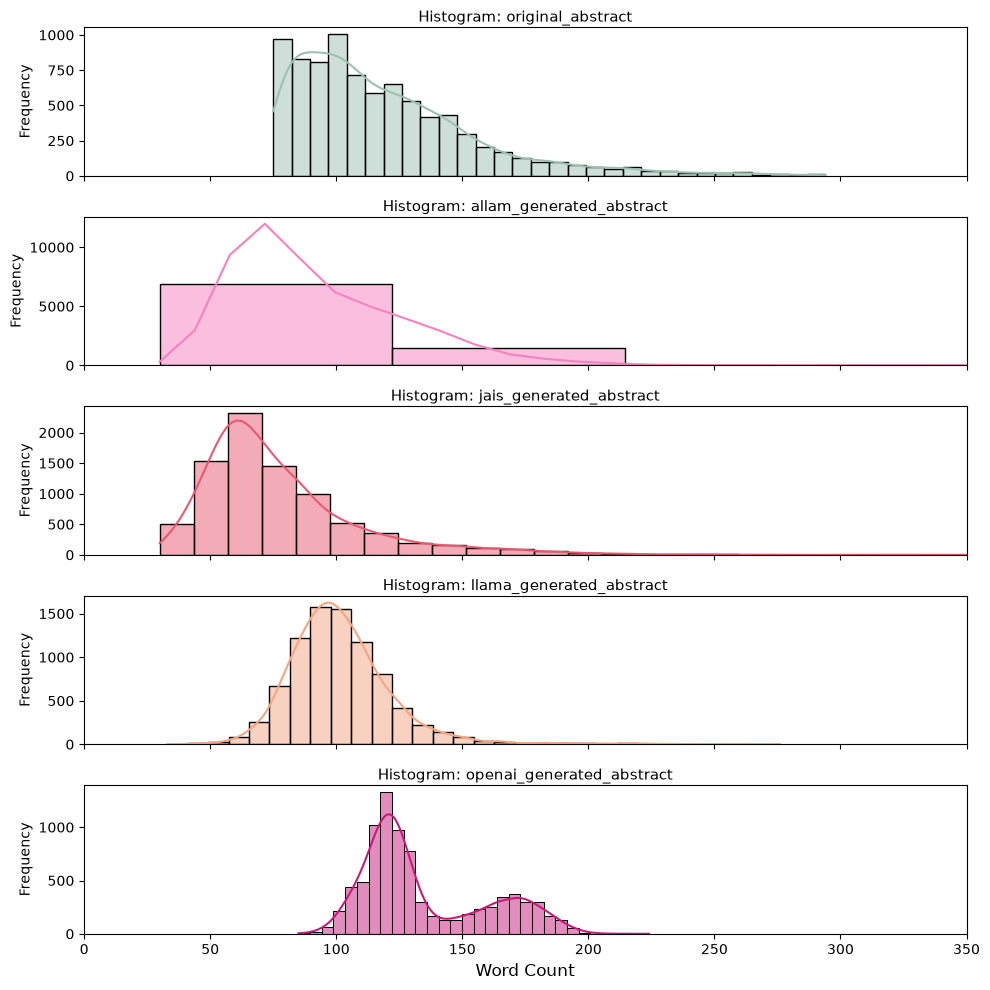

In [ ]:
# Histogram, i want to see the tails
plt.figure(figsize=(10, 5))
for col in df_counts.columns:
  sns.histplot(
      df_counts[col],
      color=custom_colors[col],
      label=col,
      element='step',
      stat='density',
      common_norm=False,
      bins=30,
      alpha=0.3,
  )

plt.title('Word Count Histograms Across Models')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.xlim(0, 350)  # Zoomed to main word count range
plt.legend(title='Abstract Source')
plt.tight_layout()
plt.show()

#Individual
fig, axes = plt.subplots(
    nrows=5, ncols=1, figsize=(10, 10), sharex=True, squeeze=True
)

for i, col in enumerate(df_counts.columns):
  sns.histplot(
      df_counts[col],
      ax=axes[i],
      color=custom_colors[col],
      bins=30,
      kde=True,  # Includes Smooth Kernel Density Estimate line
  )
  axes[i].set_title(f'Histogram: {col}', fontsize=11, pad=4)
  axes[i].set_ylabel('Frequency')
  axes[i].set_xlim(0, 350)  # Zoom

axes[-1].set_xlabel('Word Count', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Melt the coulmns for easier analysis- THIS IS PREPROCESSING THING
df_long = pd.melt(
    df,
    id_vars=['task_split'],
    value_vars=[
        'original_abstract',
        'allam_generated_abstract',
        'jais_generated_abstract',
        'llama_generated_abstract',
        'openai_generated_abstract'
    ],
    var_name='model_source',
    value_name='text'
)

# Create binary variable (0 = Human, 1 = AI)
df_long['label'] = df_long['model_source'].apply(lambda x: 'Human' if x == 'original_abstract' else 'AI')

df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 41940 entries, 0 to 41939
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   task_split    41940 non-null  str  
 1   model_source  41940 non-null  str  
 2   text          41940 non-null  str  
 3   label         41940 non-null  str  
dtypes: str(4)
memory usage: 52.1 MB
